# To run:
### Ordner (Name: mouseDataExpBCompl), der alle Participant - CSV Dateien beinhaltet auf selber Ebene wie dieses Notebook.
### und df_for_trialexclusion.csv auf selber Ebene

---------------------------------------------------------------------------------------------------------------------------------

In [2]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
folder_path = 'mouseDataExpBCompl'


exclude_ids = ['9468', '9902',  # Error Outlier
               '2786', '6382', '6892',  # Bugs
               '5883',  # Incomplete Data
               '2878', '4420', '2523', '9025']  # Touchpad User

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
filtered_files = [
    file for file in csv_files
    if not any(ex_id in os.path.basename(file) for ex_id in exclude_ids)
]

# Einlesen
dataframes = [pd.read_csv(file) for file in filtered_files]


### Alle die mit 1 in df_for_trialexclusion markiert sind rausschmeißen

In [3]:
exclusion_df = pd.read_csv('df_for_trialexclusion.csv') 
# habe in trialexecution block zu round umbenannt
excluded = exclusion_df[exclusion_df['trial_excl'] == 1][['id', 'round', 'trial']]
dataframes_without_excluded = []

for df in dataframes:
    if all(col in df.columns for col in ['id', 'round', 'trial']):
        merged = df.merge(excluded, on=['id', 'round', 'trial'], how='left', indicator=True)
        df_cleaned = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
        dataframes_without_excluded.append(df_cleaned)
    else:
        dataframes_without_excluded.append(df) 

### leere dataframes rausschmeißen

In [4]:
dataframes_without_excluded = [
    df for df in dataframes_without_excluded
    if isinstance(df, pd.DataFrame) and not df.empty
]

### in blöcke einteilen und alle Zeilen mit Waiting for Target rauswerfen

In [5]:
block_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
all_blocks = {f"{a}_{b}": [] for a, b in block_pairs}

for df in dataframes_without_excluded:
    df = df[df['phase'] != 'waitingForTarget']  # Phase-Filter
    for a, b in block_pairs:
        df_block = df[df['round'].isin([a, b])].reset_index(drop=True)
        all_blocks[f"{a}_{b}"].append(df_block)

In [6]:
all_blocks["1_2"][0].iloc[0:50]

,id,round,trial,version,timestamp,frame,relative_time,mouse_x,mouse_y,mouse_dx,mouse_dy,phase,event
0,1085,1,2,lld,14:14:18.273,8389,0.017,0.101,0.023,0.0,0.0,activeTracking,targetAppeared
1,1085,1,2,lld,14:14:18.289,8390,0.034,0.101,0.023,0.0,0.0,activeTracking,noEvent
2,1085,1,2,lld,14:14:18.307,8391,0.051,0.101,0.023,0.0,0.0,activeTracking,noEvent
3,1085,1,2,lld,14:14:18.323,8392,0.068,0.101,0.023,0.0,0.0,activeTracking,noEvent
4,1085,1,2,lld,14:14:18.340,8393,0.084,0.101,0.023,0.0,0.0,activeTracking,noEvent
5,1085,1,2,lld,14:14:18.356,8394,0.101,0.101,0.023,0.0,0.0,activeTracking,noEvent
6,1085,1,2,lld,14:14:18.372,8395,0.117,0.101,0.023,0.0,0.0,activeTracking,noEvent
7,1085,1,2,lld,14:14:18.388,8396,0.133,0.101,0.023,0.0,0.0,activeTracking,noEvent
8,1085,1,2,lld,14:14:18.406,8397,0.150,0.101,0.023,0.0,0.0,activeTracking,noEvent
9,1085,1,2,lld,14:14:18.422,8398,0.167,0.101,0.023,0.0,0.0,activeTracking,noEvent


In [7]:
def get_target_loc(mouse_x):
    if len(mouse_x) < 2:
        return None
    if mouse_x[-1] > mouse_x[0]:
        return "right"
    elif mouse_x[-1] < mouse_x[0]:
        return "left"
    else:
        return "none"


In [8]:
def get_delay(version, target_loc):
    if target_loc is None or target_loc == "none":
        return None

    if version == "rld" and target_loc == "right":
        return 1
    if version == "rld" and target_loc == "left":
        return 0
    if version == "lld" and target_loc == "left":
        return 1
    if version == "lld" and target_loc == "right":
        return 0

    return None


In [9]:
def compute_rel_time(timestamp_list):
    if not timestamp_list:
        return []

    t = pd.to_datetime(
        timestamp_list,
        format="%H:%M:%S.%f"
    )

    rel_time = (t - t[0]).total_seconds()
    return rel_time.tolist()


In [10]:
def compute_dist_to_target_from_endpoint(mouse_x, mouse_y):
    x = np.array(mouse_x)
    y = np.array(mouse_y)

    x_end = x[-1]
    y_end = y[-1]

    dist = np.sqrt((x - x_end)**2 + (y - y_end)**2)
    return dist.tolist()

In [11]:
def compute_dist_prop(dist_list):
    """
    Computes proportional Euclidean distance as in Hehman et al., 2015
    dist_list: Liste der Abstände zum Ziel (dist_to_target)
    """
    dist_arr = np.array(dist_list)
    dist_max = np.max(dist_arr)
    
    if dist_max > 0:
        dist_prop = 1 - dist_arr / dist_max
    else:
        dist_prop = np.full_like(dist_arr, np.nan, dtype=float)
    
    return dist_prop.tolist()


In [12]:
def compute_rt_05pct_target(mouse_x_list, mouse_y_list, rel_time_list, threshold_pct=0.05):
    """
    Berechnet die Reaktionszeit (Bewegungsinitiierung) für einen Trial.

    Parameters
    ----------
    mouse_x_list : list oder np.array
        X-Koordinaten der Mausbewegung
    mouse_y_list : list oder np.array
        Y-Koordinaten der Mausbewegung
    rel_time_list : list oder np.array
        Relative Zeit ab Target appearance (bereits vorhanden)
    threshold_pct : float
        Prozentualer Anteil der Gesamtstrecke, ab dem Bewegung zählt (default=0.05)

    Returns
    -------
    rt : float
        Reaktionszeit in Sekunden (erste Bewegung > threshold), np.nan falls nie erreicht
    """
    mouse_x = np.array(mouse_x_list)
    mouse_y = np.array(mouse_y_list)
    rel_time = np.array(rel_time_list)

    start_x, start_y = mouse_x[0], mouse_y[0]
    end_x, end_y = mouse_x[-1], mouse_y[-1]

    total_distance = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)
    threshold_distance = threshold_pct * total_distance

    dist_to_target = np.sqrt((end_x - mouse_x)**2 + (end_y - mouse_y)**2)
    progr_toward_target = dist_to_target[0] - dist_to_target 

    indices = np.where(progr_toward_target >= threshold_distance)[0]

    if len(indices) == 0:
        return np.nan 

    return rel_time[indices[0]]


### Nur timestamp, mouse_x, mouse_y, version und id behalten und die trials gruppieren -> 1 trial in einer Zeile

In [13]:
grouped_blocks = {
    '1_2': [],
    '3_4': [],
    '5_6': [],
    '7_8': [],
    '9_10': [],
    '11_12': [],
    '13_14': [],
    '15_16': []
}

for key in grouped_blocks.keys():
    for df in all_blocks[key]:
        df_grouped = df.groupby(['round', 'trial']).agg({
            'timestamp': list,
            'mouse_x': list,
            'mouse_y': list,
            'version': 'first',
            'id': 'first'
        }).reset_index()
        df_grouped['target_loc'] = df_grouped['mouse_x'].apply(get_target_loc)

        df_grouped['delay'] = df_grouped.apply(
            lambda row: get_delay(row['version'], row['target_loc']),
            axis=1
        )
        df_grouped['rel_time'] = df_grouped['timestamp'].apply(compute_rel_time)

        df_grouped['dist_to_target'] = df_grouped.apply(
            lambda row: compute_dist_to_target_from_endpoint(
                row['mouse_x'],
                row['mouse_y']
            ),
            axis=1
        )

        df_grouped['dist_prop'] = df_grouped['dist_to_target'].apply(compute_dist_prop)

        df_grouped['rt_05pct_target'] = df_grouped.apply(
            lambda row: compute_rt_05pct_target(
                row['mouse_x'], row['mouse_y'], row['rel_time']
            ),
            axis=1
        )

        df_grouped['rt'] = df_grouped['rel_time'].apply(lambda x: x[-1] if len(x) > 0 else None)

        grouped_blocks[key].append(df_grouped)


In [14]:
grouped_blocks["1_2"][0].head()

,round,trial,timestamp,mouse_x,mouse_y,version,id,target_loc,delay,rel_time,dist_to_target,dist_prop,rt_05pct_target,rt
0,1,2,"[14:14:18.273, 14:14:18.289, 14:14:18.307, 14:...","[0.101, 0.101, 0.101, 0.101, 0.101, 0.101, 0.1...","[0.023, 0.023, 0.023, 0.023, 0.023, 0.023, 0.0...",lld,1085,right,0,"[0.0, 0.016, 0.034, 0.05, 0.067, 0.083, 0.099,...","[2.7651887819821632, 2.7651887819821632, 2.765...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.283,1.299
1,1,3,"[14:14:21.623, 14:14:21.639, 14:14:21.657, 14:...","[0.236, 0.236, 0.225, 0.221, 0.22, 0.219, 0.20...","[0.006, 0.006, -0.006, -0.009, -0.011, -0.011,...",lld,1085,left,1,"[0.0, 0.016, 0.034, 0.049, 0.066, 0.084, 0.1, ...","[2.841356366244826, 2.841356366244826, 2.83019...","[0.018487591632894818, 0.018487591632894818, 0...",0.366,1.384
2,1,4,"[14:14:25.489, 14:14:25.507, 14:14:25.523, 14:...","[0.016, 0.039, 0.047, 0.049, 0.073, 0.08, 0.11...","[0.175, 0.175, 0.175, 0.175, 0.175, 0.175, 0.1...",lld,1085,left,1,"[0.0, 0.018, 0.034, 0.051, 0.068, 0.085, 0.1, ...","[2.7193388902452007, 2.742159915103421, 2.7500...","[0.4869836829145384, 0.482678387180021, 0.4811...",0.317,2.050
3,1,5,"[14:14:30.040, 14:14:30.056, 14:14:30.073, 14:...","[0.101, 0.101, 0.101, 0.112, 0.116, 0.117, 0.1...","[-0.062, -0.062, -0.062, -0.062, -0.062, -0.06...",lld,1085,right,0,"[0.0, 0.016, 0.033, 0.049, 0.065, 0.082, 0.099...","[2.7296959537648147, 2.7296959537648147, 2.729...","[0.0, 0.0, 0.0, 0.004024274566087005, 0.005487...",0.217,0.983
4,1,6,"[14:14:33.072, 14:14:33.089, 14:14:33.106, 14:...","[0.236, 0.236, 0.236, 0.236, 0.236, 0.236, 0.2...","[-0.281, -0.281, -0.281, -0.281, -0.281, -0.28...",lld,1085,right,0,"[0.0, 0.017, 0.034, 0.051, 0.067, 0.084, 0.102...","[2.440464095208122, 2.440464095208122, 2.44046...","[0.031193521125842283, 0.031193521125842283, 0...",0.284,1.570


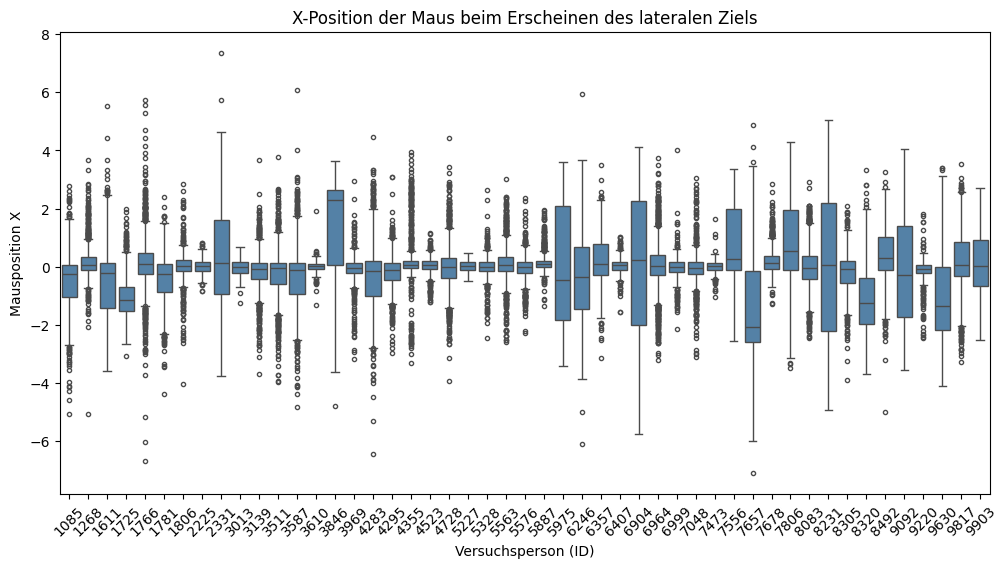

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
for key in grouped_blocks.keys():
    for df in grouped_blocks[key]:
        for _, row in df.iterrows():
            if len(row['mouse_x']) > 0:
                rows.append({
                    'id': row['id'],
                    'first_mouse_x': row['mouse_x'][0]
                })

df_first_x = pd.DataFrame(rows)

plt.figure(figsize=(12,6))
sns.boxplot(x='id', y='first_mouse_x', data=df_first_x, color='steelblue', fliersize=3)
plt.title("X-Position der Maus beim Erscheinen des lateralen Ziels")
plt.xlabel("Versuchsperson (ID)")
plt.ylabel("Mausposition X")
plt.xticks(rotation=45)
plt.show()


C:\Users\m_uel\AppData\Local\Temp\ipykernel_3460\241302925.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  timestamps = pd.to_datetime(trial_row['timestamp'])


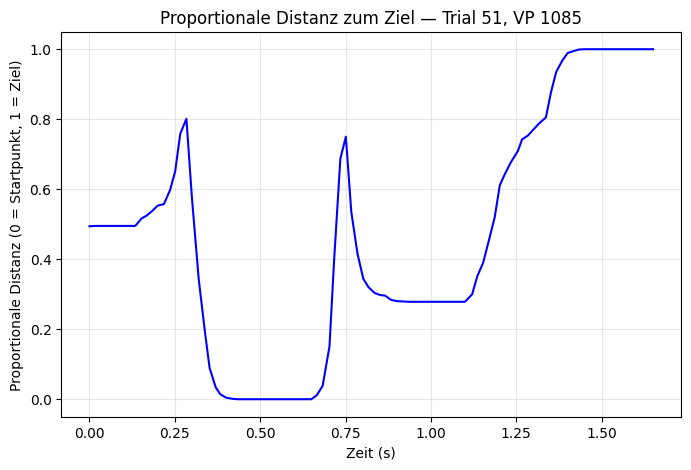

In [16]:
df = grouped_blocks["1_2"][0]
trial_row = df[(df['id'] == 1085) & (df['round'] == 1) & (df['trial'] == 51)].iloc[0]

timestamps = pd.to_datetime(trial_row['timestamp'])
rel_time = (timestamps - timestamps[0]).total_seconds()
dist_prop = trial_row['dist_prop']

plt.figure(figsize=(8,5))
plt.plot(rel_time, dist_prop, color='blue')
plt.title("Proportionale Distanz zum Ziel — Trial 51, VP 1085")
plt.xlabel("Zeit (s)")
plt.ylabel("Proportionale Distanz (0 = Startpunkt, 1 = Ziel)")
plt.grid(alpha=0.3)
plt.show()

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_first_n_trials_with_rt(df, participant_id, round_num, n_first=5):
    """
    Plottet proportionale Distanz zum Ziel für die ersten `n_first` Trials einer Runde
    und markiert die Bewegungsinitiierung (rt_05pct_target) als senkrechte Linie.
    
    df: DataFrame eines Blocks
    participant_id: ID der Versuchsperson
    round_num: Runde die geplottet werden soll
    n_first: Anzahl der ersten Trials, die geplottet werden sollen
    """
    
    trials = df[(df['id'] == participant_id) & (df['round'] == round_num)]
    

    trials = trials.sort_values('trial').head(n_first)
    
    for _, trial_row in trials.iterrows():
        dist_prop = trial_row['dist_prop']

        rt_sec = trial_row.get('rt_05pct_target', None)
        
        plt.figure(figsize=(8,5))
        plt.plot(trial_row["rel_time"], dist_prop, color='blue')
        if rt_sec is not None:
            plt.axvline(x=rt_sec, color='red', linestyle='--', label='Bewegungsinitiierung')
        plt.title(f"Proportionale Distanz zum Ziel — Trial {trial_row['trial']}, VP {participant_id}")
        plt.xlabel("Zeit (s)")
        plt.ylabel("Proportionale Distanz (0 = Startpunkt, 1 = Ziel)")
        plt.ylim(0, 1.05)
        if rt_sec is not None:
            plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


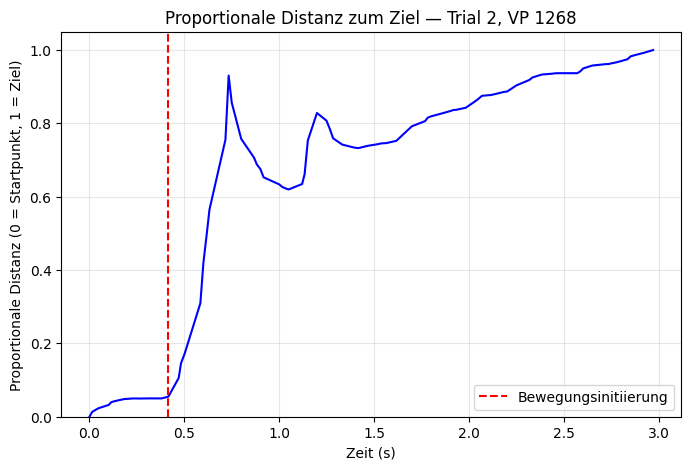

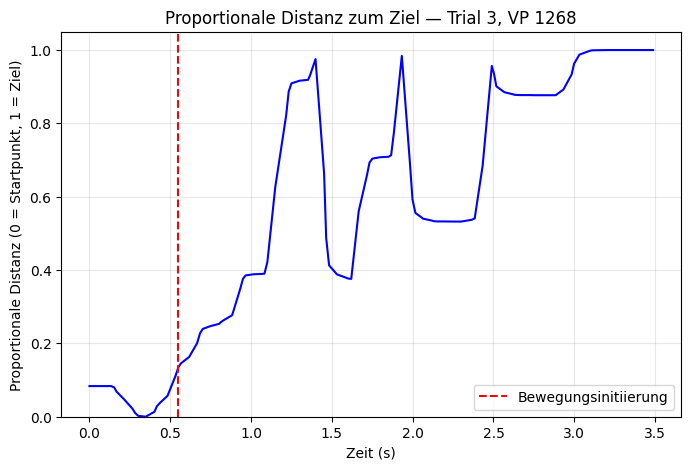

In [18]:
df = grouped_blocks["1_2"][1]
plot_first_n_trials_with_rt(df, participant_id=1268, round_num=1, n_first=2)


In [19]:
all_trials = []

for block_key, dfs in grouped_blocks.items():
    for df in dfs:
        for _, row in df.iterrows():
            all_trials.append({
                'id': row['id'],
                'version': row['version'],
                'block_f': block_key,
                'delay': row['delay'],
                'rt': row["rt_05pct_target"],
                'dist_to_target_start': row['dist_to_target'][0]
            })

# Alle Trials in ein DataFrame
df_rt = pd.DataFrame(all_trials)

df_rt_means = df_rt.groupby(['id', 'version', 'block_f', 'delay']).agg(
    rt_mean=('rt', 'mean'),
    dist_to_target_start=('dist_to_target_start', 'first')
).reset_index()

print(df_rt_means)


       id version block_f  delay   rt_mean  dist_to_target_start
0    1085     lld   11_12    0.0  0.272246              3.286742
1    1085     lld   11_12    1.0  0.133130              1.859129
2    1085     lld   13_14    0.0  0.243617              5.239441
3    1085     lld   13_14    1.0  0.182691              2.038654
4    1085     lld   15_16    0.0  0.260516              3.461451
..    ...     ...     ...    ...       ...                   ...
779  9903     lld     5_6    1.0  0.292158              2.220014
780  9903     lld     7_8    0.0  0.239033              3.903883
781  9903     lld     7_8    1.0  0.305818              4.004231
782  9903     lld    9_10    0.0  0.228362              3.621199
783  9903     lld    9_10    1.0  0.285611              1.712263

[784 rows x 6 columns]


In [20]:
# Mittelwerte über alle Teilnehmer pro Block und Delay
summary = df_rt_means.groupby(['block_f', 'delay']).agg(
    rt_mean_avg=('rt_mean', 'mean'),
    rt_mean_sd=('rt_mean', 'std'),
    n=('rt_mean', 'count')
).reset_index()

print(summary)

   block_f  delay  rt_mean_avg  rt_mean_sd   n
0    11_12    0.0     0.227475    0.122776  49
1    11_12    1.0     0.277004    0.105767  49
2    13_14    0.0     0.227234    0.127763  49
3    13_14    1.0     0.280866    0.112604  49
4    15_16    0.0     0.218342    0.123939  49
5    15_16    1.0     0.278895    0.111612  49
6      1_2    0.0     0.264999    0.111097  49
7      1_2    1.0     0.277468    0.111627  49
8      3_4    0.0     0.258926    0.125656  49
9      3_4    1.0     0.271557    0.109920  49
10     5_6    0.0     0.247059    0.122496  49
11     5_6    1.0     0.271070    0.104389  49
12     7_8    0.0     0.243926    0.115351  49
13     7_8    1.0     0.268241    0.100405  49
14    9_10    0.0     0.239507    0.112427  49
15    9_10    1.0     0.276214    0.099158  49


In [21]:
pivot = df_rt_means.pivot_table(
    values='rt_mean', 
    index='block_f', 
    columns='delay', 
    aggfunc=['mean', 'std'] 
)

print(pivot)

             mean                 std          
delay         0.0       1.0       0.0       1.0
block_f                                        
11_12    0.227475  0.277004  0.122776  0.105767
13_14    0.227234  0.280866  0.127763  0.112604
15_16    0.218342  0.278895  0.123939  0.111612
1_2      0.264999  0.277468  0.111097  0.111627
3_4      0.258926  0.271557  0.125656  0.109920
5_6      0.247059  0.271070  0.122496  0.104389
7_8      0.243926  0.268241  0.115351  0.100405
9_10     0.239507  0.276214  0.112427  0.099158


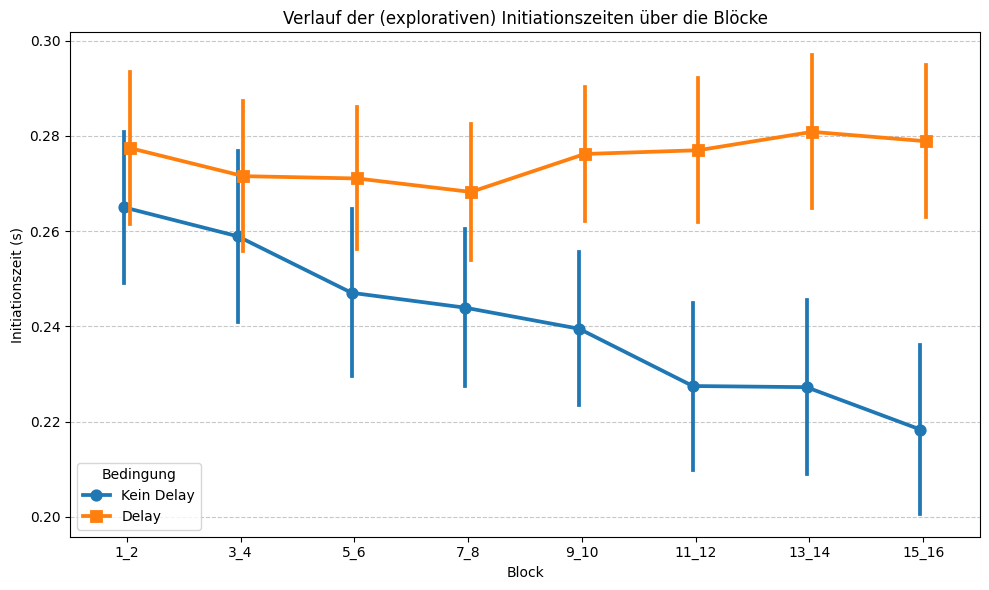

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_order = ["1_2", "3_4", "5_6", "7_8", "9_10", "11_12", "13_14", "15_16"]

plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df_rt_means,
    x="block_f",
    y="rt_mean",
    hue="delay",
    order=pair_order,
    errorbar="se",
    dodge=True,  
    markers=["o", "s"]
)

plt.ylabel("Initiationszeit (s)")
plt.xlabel("Block")
plt.title("Verlauf der (explorativen) Initiationszeiten über die Blöcke")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Kein Delay", "Delay"], title="Bedingung")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

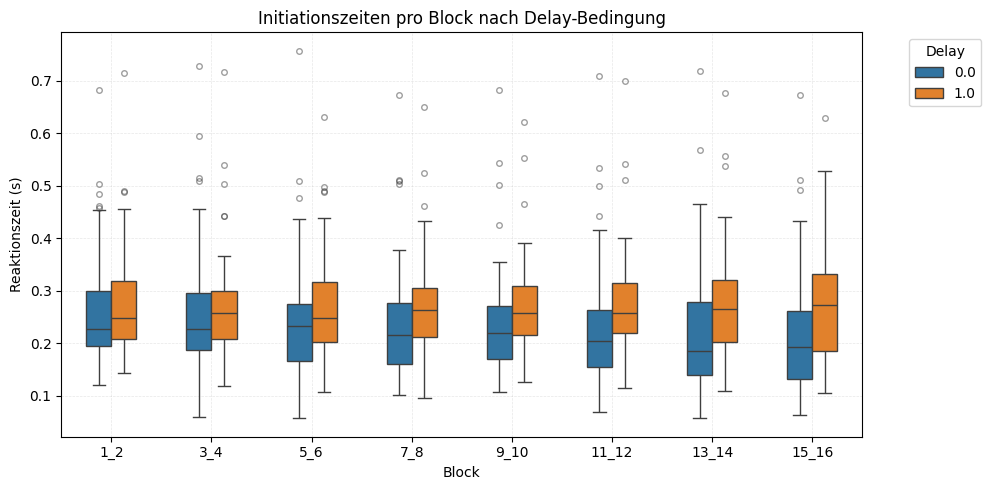

In [23]:
block_order = ['1_2','3_4','5_6','7_8','9_10','11_12','13_14','15_16']
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_rt_means,
    x='block_f',
    y='rt_mean',
    hue='delay',
    order=block_order,
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

plt.title("Initiationszeiten pro Block nach Delay-Bedingung")
plt.xlabel("Block")
plt.ylabel("Reaktionszeit (s)")
plt.legend(title='Delay')
plt.legend(title='Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()


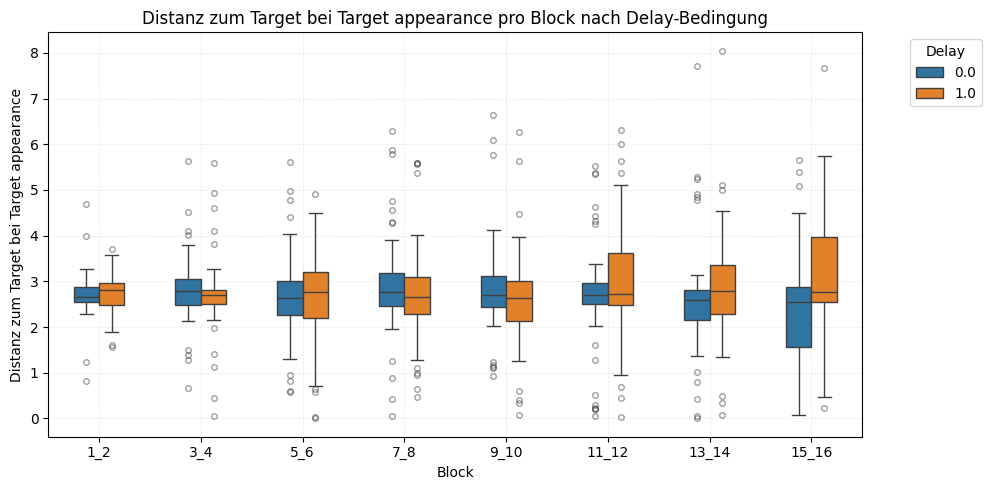

In [24]:
plt.figure(figsize=(10, 5))

box = sns.boxplot(
    data=df_rt_means, 
    x='block_f',               
    y='dist_to_target_start',
    hue='delay',                       
    order=block_order,
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

plt.title("Distanz zum Target bei Target appearance pro Block nach Delay-Bedingung")
plt.xlabel("Block")
plt.ylabel("Distanz zum Target bei Target appearance")
plt.legend(title='Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()


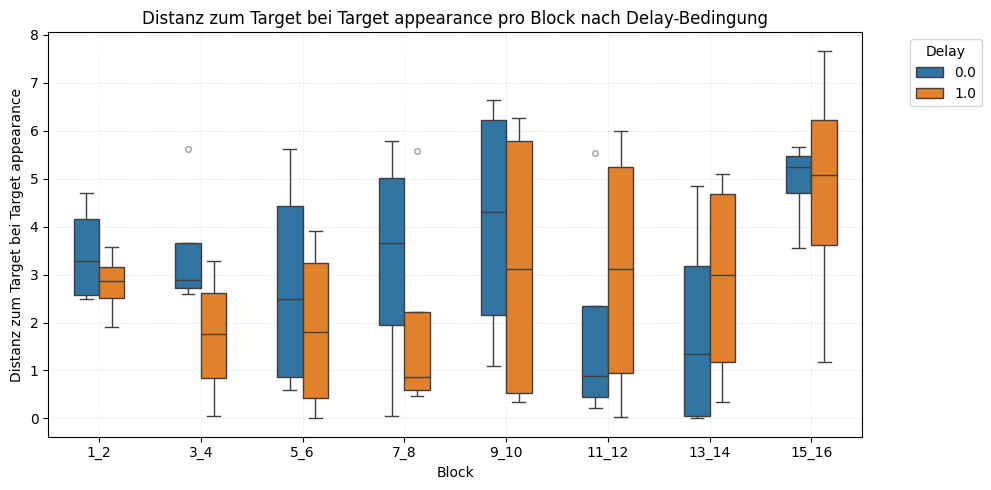

In [25]:
# Nur diese IDs behalten
filter_ids = [3846, 6904, 7657, 8231]
df_filtered = df_rt_means[df_rt_means['id'].isin(filter_ids)]

plt.figure(figsize=(10, 5))

box = sns.boxplot(
    data=df_filtered,
    x='block_f',               
    y='dist_to_target_start',
    hue='delay',                       
    order=block_order,
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

plt.title("Distanz zum Target bei Target appearance pro Block nach Delay-Bedingung")
plt.xlabel("Block")
plt.ylabel("Distanz zum Target bei Target appearance")
plt.legend(title='Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()